# Lecture 11 — Convolutional Networks

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

A convolution looks at a small patch of the input and slides the **same** small filter everywhere.
This notebook builds convolution three ways and checks them against each other, runs a real edge
detector on a digit, measures the parameter savings, and verifies the lecture's central trick for the
backward pass: **the transpose of a convolution is a convolution with the flipped filter.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
rng = np.random.default_rng(0)

## 1. The operation, on the note's example

An image that is flat on the left with a bright edge on the right, and a filter that subtracts the
left column from the right column. Each output is the sum of (patch × filter).

In [2]:
def conv2d_naive(X, W):
    """'valid' convolution (ML convention: no filter flip). X: (H, Wd). W: (k, k)."""
    k = W.shape[0]
    H, Wd = X.shape[0] - k + 1, X.shape[1] - k + 1
    return np.array([[np.sum(X[i:i+k, j:j+k] * W) for j in range(Wd)] for i in range(H)])

X = np.array([[0, 0, 0, 5, 5]] * 5, dtype=float)
W = np.array([[-1, 0, 1]] * 3, dtype=float)
print("input:\n", X, "\n\nfilter:\n", W, "\n\noutput:\n", conv2d_naive(X, W))

input:
 [[0. 0. 0. 5. 5.]
 [0. 0. 0. 5. 5.]
 [0. 0. 0. 5. 5.]
 [0. 0. 0. 5. 5.]
 [0. 0. 0. 5. 5.]] 

filter:
 [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]] 

output:
 [[ 0. 15. 15.]
 [ 0. 15. 15.]
 [ 0. 15. 15.]]


0 where the patch sits on flat ground, 15 where it straddles the edge: an edge detector from 9 numbers.

## 2. A real image

Apply a horizontal and a vertical gradient filter to a digit and combine them as $\sqrt{g_x^2 + g_y^2}$
— the classical first step of edge detection.

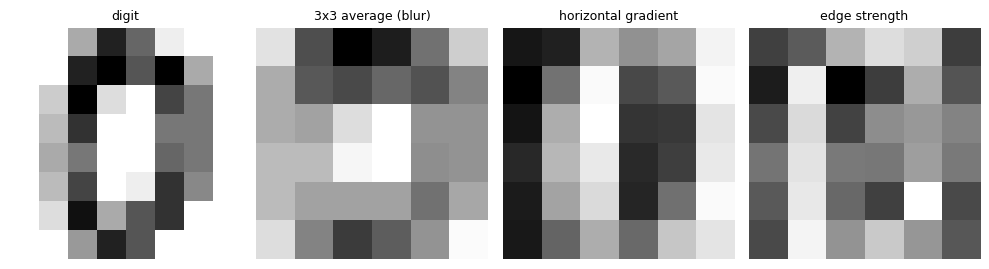

In [3]:
img = load_digits().images[0]
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
gx, gy = conv2d_naive(img, sobel_x), conv2d_naive(img, sobel_x.T)
blur = conv2d_naive(img, np.ones((3, 3)) / 9)

fig, ax = plt.subplots(1, 4, figsize=(10, 2.8))
for a_, im, t in zip(ax, [img, blur, gx, np.sqrt(gx**2 + gy**2)],
                     ["digit", "3x3 average (blur)", "horizontal gradient", "edge strength"]):
    a_.imshow(im, cmap="gray_r"); a_.set_title(t, fontsize=9); a_.axis("off")
plt.tight_layout(); plt.show()

## 3. Why not a fully connected layer?

In [4]:
for name, n in [("MNIST 28x28", 28*28), ("256x256 greyscale", 256*256)]:
    print(f"{name:<20} fully connected to same size: {n*n:>16,} weights   3x3 conv: 9")
print(f"\n3x3 conv, 64 -> 128 channels : {9*64*128:,} weights")
print(f"depthwise 3x3, 64 channels   : {9*64:,} weights")

MNIST 28x28          fully connected to same size:          614,656 weights   3x3 conv: 9
256x256 greyscale    fully connected to same size:    4,294,967,296 weights   3x3 conv: 9

3x3 conv, 64 -> 128 channels : 73,728 weights
depthwise 3x3, 64 channels   : 576 weights


## 4. Multi-channel convolution, and im2col

With channels, each pixel is a vector and each filter entry a $C_{out}\times C_{in}$ matrix. im2col
stacks every shifted copy of the input into one matrix so the whole convolution becomes **one matrix
multiply**. Check it against a naive four-nested-loop version.

In [5]:
def conv_naive_mc(X, W):
    """X: (H, Wd, Cin). W: (k, k, Cin, Cout). Same padding, stride 1."""
    k = W.shape[0]; p = (k - 1) // 2
    H, Wd, _ = X.shape
    Xp = np.pad(X, ((p, p), (p, p), (0, 0)))
    out = np.zeros((H, Wd, W.shape[3]))
    for r in range(H):
        for c in range(Wd):
            for i in range(k):
                for j in range(k):
                    out[r, c] += Xp[r + i, c + j] @ W[i, j]     # vector times matrix
    return out

def conv_im2col(X, W):
    k, H, Wd = W.shape[0], X.shape[0], X.shape[1]
    p = (k - 1) // 2
    Xp = np.pad(X, ((p, p), (p, p), (0, 0)))
    cols = np.stack([Xp[i:i+H, j:j+Wd] for i in range(k) for j in range(k)], axis=2)
    A = cols.reshape(H * Wd, -1)                                  # the im2col matrix
    return (A @ W.reshape(-1, W.shape[3])).reshape(H, Wd, -1)     # ONE matmul

X = rng.normal(size=(8, 9, 3)); W = rng.normal(size=(3, 3, 3, 5))
print("im2col == naive:", np.allclose(conv_im2col(X, W), conv_naive_mc(X, W)))
print("output shape   :", conv_im2col(X, W).shape, " (same H, W thanks to padding)")

im2col == naive: True
output shape   : (8, 9, 5)  (same H, W thanks to padding)


## 5. Output sizes: padding, stride, dilation

A $k\times k$ filter with dilation $d$ covers $d(k-1)+1$ pixels. With padding $p$ and stride $s$, the
output size is $\lfloor (n + 2p - d(k-1) - 1)/s \rfloor + 1$.

In [6]:
def out_size(n, k, p=0, s=1, d=1):
    return (n + 2*p - d*(k - 1) - 1) // s + 1

cases = [("no padding", 5, 3, 0, 1, 1), ("pad (k-1)/2", 4, 3, 1, 1, 1),
         ("stride 2", 8, 3, 1, 2, 1), ("dilation 2, pad 1", 5, 3, 1, 1, 2),
         ("dilation 2, pad 2", 5, 3, 2, 1, 2)]
for name, n, k, p, s, d in cases:
    print(f"{name:<18} n={n}, k={k}: output {out_size(n, k, p, s, d)}")

no padding         n=5, k=3: output 3
pad (k-1)/2        n=4, k=3: output 4
stride 2           n=8, k=3: output 4
dilation 2, pad 1  n=5, k=3: output 3
dilation 2, pad 2  n=5, k=3: output 5


Dilation spreads the filter wider, so it needs more padding to keep the size — exactly the catch the
lecture warns about.

## 6. Pooling

In [7]:
P = np.array([[1, 3, 2, 0], [4, 2, 1, 1], [0, 1, 5, 2], [2, 0, 3, 4]], dtype=float)
blocks = P.reshape(2, 2, 2, 2).swapaxes(1, 2)
print("max pool:\n", blocks.max(axis=(2, 3)), "\naverage pool:\n", blocks.mean(axis=(2, 3)))

max pool:
 [[4. 2.]
 [2. 5.]] 
average pool:
 [[2.5  1.  ]
 [0.75 3.5 ]]


## 7. The backward pass: transpose = flipped filter

A convolution is linear, so it is multiplication by some matrix $\widehat W$. Build that matrix for a
1-D convolution of length 5 with padding 1 and check the lecture's claim directly.

In [8]:
def conv1d(x, w):
    xp = np.pad(x, 1)
    return np.array([xp[i:i+3] @ w for i in range(len(x))])

w = np.array([1.0, 2.0, 3.0])
W_hat = np.zeros((5, 5))
for i in range(5):
    for k in range(3):
        if 0 <= i + k - 1 < 5:
            W_hat[i, i + k - 1] = w[k]
print("W_hat =\n", W_hat, "\n\nW_hat.T =\n", W_hat.T)

x, v = rng.normal(size=5), rng.normal(size=5)
print("\nW_hat @ x   == conv(x, w)          :", np.allclose(W_hat @ x, conv1d(x, w)))
print("W_hat.T @ v == conv(v, flipped w)  :", np.allclose(W_hat.T @ v, conv1d(v, w[::-1])))

W_hat =
 [[2. 3. 0. 0. 0.]
 [1. 2. 3. 0. 0.]
 [0. 1. 2. 3. 0.]
 [0. 0. 1. 2. 3.]
 [0. 0. 0. 1. 2.]] 

W_hat.T =
 [[2. 1. 0. 0. 0.]
 [3. 2. 1. 0. 0.]
 [0. 3. 2. 1. 0.]
 [0. 0. 3. 2. 1.]
 [0. 0. 0. 3. 2.]]

W_hat @ x   == conv(x, w)          : True
W_hat.T @ v == conv(v, flipped w)  : True


In [9]:
# The same holds in 2-D, where the filter is flipped both ways.
def conv2d_same(X, W):
    p = (W.shape[0] - 1) // 2
    return conv2d_naive(np.pad(X, p), W)

n, k = 6, 3
W2 = rng.normal(size=(k, k))
M = np.zeros((n*n, n*n))                          # the full matrix, one column per input pixel
for idx in range(n*n):
    e = np.zeros(n*n); e[idx] = 1
    M[:, idx] = conv2d_same(e.reshape(n, n), W2).ravel()

V = rng.normal(size=(n, n))
lhs = (M.T @ V.ravel()).reshape(n, n)
rhs = conv2d_same(V, W2[::-1, ::-1])
print("2-D: transpose of conv == conv with filter flipped up-down and left-right:", np.allclose(lhs, rhs))

2-D: transpose of conv == conv with filter flipped up-down and left-right: True


### And the weight gradient comes from im2col

Written as $z = \widehat X w$, the derivative with respect to the filter is just $\widehat X$ (the im2col
matrix). So for a loss $\ell$, $\nabla_w \ell = \widehat X^{\mathsf T}\, \nabla_z \ell$. Checked against
finite differences:

In [10]:
X = rng.normal(size=(5, 6, 2)); W = rng.normal(size=(3, 3, 2, 4)); G = rng.normal(size=(5, 6, 4))
loss = lambda W_: np.sum(conv_im2col(X, W_) * G)             # an arbitrary scalar of the output

p = 1; Xp = np.pad(X, ((p, p), (p, p), (0, 0)))
cols = np.stack([Xp[i:i+5, j:j+6] for i in range(3) for j in range(3)], axis=2).reshape(30, -1)
grad_im2col = (cols.T @ G.reshape(30, -1)).reshape(W.shape)

num, eps = np.zeros_like(W), 1e-6
for idx in np.ndindex(*W.shape):
    Wp, Wm = W.copy(), W.copy(); Wp[idx] += eps; Wm[idx] -= eps
    num[idx] = (loss(Wp) - loss(Wm)) / (2 * eps)
print("weight gradient via im2col, max |error| =", np.abs(grad_im2col - num).max())

weight gradient via im2col, max |error| = 5.75079517339816e-09


## Summary

- A convolution is local and weight-shared: 9 weights instead of 4.3 billion for a $256\times256$ layer.
- A $[-1,0,1]$-style filter is an edge detector; on a real digit, two gradient filters outline the stroke.
- im2col turns a multi-channel convolution into one matrix multiply — identical to the naive loops.
- Multiplying by the transpose of a convolution equals convolving with the flipped filter, verified in
  1-D and 2-D. That is the input gradient.
- The weight gradient is $\widehat X^{\mathsf T}\nabla_z\ell$ from the im2col matrix, verified numerically.